***Random Imputation*** (also called Random Sample Imputation) is a technique for handling missing data — it replaces missing values with randomly selected values from the same variable’s existing (non-missing) data.

***When NOT to use it***

If your data has many missing values (it can distort relationships).

If the variable is not Missing Completely at Random (MCAR) — i.e., if missingness depends on other factors, this method can introduce bias.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split

In [15]:
df = pd.read_csv(
    r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\tested.csv", usecols=['Age', 'Fare', 'Survived'])

In [16]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [17]:
df.isnull().mean()*100

Survived     0.000000
Age         20.574163
Fare         0.239234
dtype: float64

In [18]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [19]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=0)

In [20]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [21]:
x_train

,Age,Fare,Age_imputed
20,55.0,59.4000,55.0
306,30.0,151.5500,30.0
142,61.0,262.3750,61.0
14,47.0,61.1750,47.0
284,2.0,20.2125,2.0
...,...,...,...
323,33.0,26.5500,33.0
192,11.5,14.5000,11.5
117,1.0,16.7000,1.0
47,NaN,7.7500,NaN


In [31]:
x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).values
x_test['Age_imputed'][x_test['Age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age_imputed'].isnull().sum()).values

C:\Users\Acer\AppData\Local\Temp\ipykernel_18296\2575304553.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).v

In [32]:
x_train

,Age,Fare,Age_imputed
20,55.0,59.4000,55.0
306,30.0,151.5500,30.0
142,61.0,262.3750,61.0
14,47.0,61.1750,47.0
284,2.0,20.2125,2.0
...,...,...,...
323,33.0,26.5500,33.0
192,11.5,14.5000,11.5
117,1.0,16.7000,1.0
47,NaN,7.7500,33.0


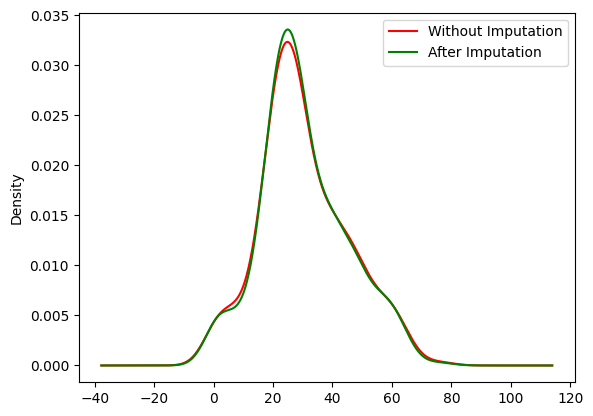

In [42]:
x_train['Age'].plot( kind = 'kde' , color = 'red' , label = 'Without Imputation')
x_train['Age_imputed'].plot(kind = 'kde' , color = 'green' , label = 'After Imputation')
plt.legend()

In [43]:
print('Original variable variance: ' , x_train['Age'].var())
print('Imputed variable variance: ' , x_train['Age_imputed'].var())

Original variable variance:  217.1999017210519
Imputed variable variance:  209.4283787524051


In [44]:
x_train[['Age','Fare' ,'Age_imputed']].cov()

,Age,Fare,Age_imputed
Age,217.199902,319.306905,217.199902
Fare,319.306905,3243.139439,251.938134
Age_imputed,217.199902,251.938134,209.428379


<Axes: >

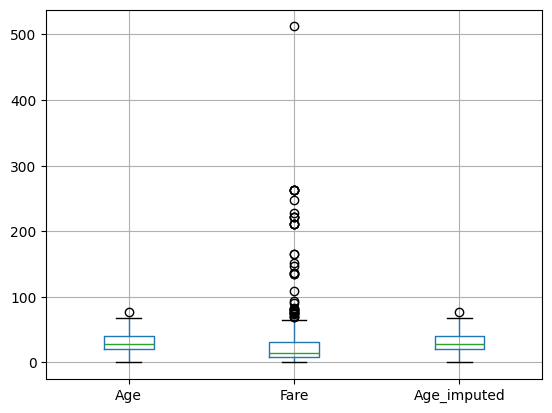

In [45]:
x_train[['Age', 'Fare' ,'Age_imputed']].boxplot()

In categorical data

In [47]:
data = pd.read_csv(
    r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\train.csv" , usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [48]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [49]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [50]:
X = data
y = data['SalePrice']

In [51]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [52]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [53]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
764,Gd,TA,270000,TA,Gd
817,Gd,TA,271000,TA,Gd
1174,Gd,TA,239000,TA,Gd
1038,TA,NaN,97000,NaN,TA
984,NaN,TA,126000,TA,NaN


In [54]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull(
)] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull(
)] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull(
)] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull(
)] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\Acer\AppData\Local\Temp\ipykernel_18296\2483337409.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull(
C:\Users\Acer\AppData\Local\Temp\ipykernel_18296\2483337409.p

In [55]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts(
        ) / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ],
    axis=1)

temp.columns = ['original', 'imputed']

In [56]:
temp

,original,imputed
TA,0.951043,0.947774
Fa,0.037171,0.040240
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [57]:
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts(
        ) / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts() / len(df)
    ],
    axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,1.375598
TA,0.412439,1.155502
Fa,0.040917,0.117225
Po,0.027823,0.076555
Ex,0.024550,0.069378


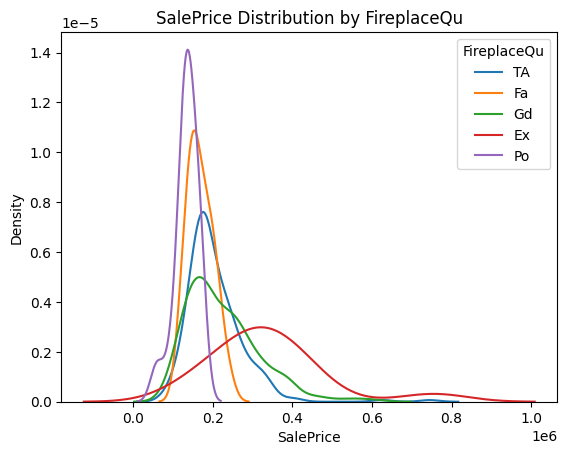

In [63]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]
                ['SalePrice'], label=category)
plt.legend(title="FireplaceQu")
plt.xlabel("SalePrice")
plt.ylabel("Density")
plt.title("SalePrice Distribution by FireplaceQu")
plt.show()

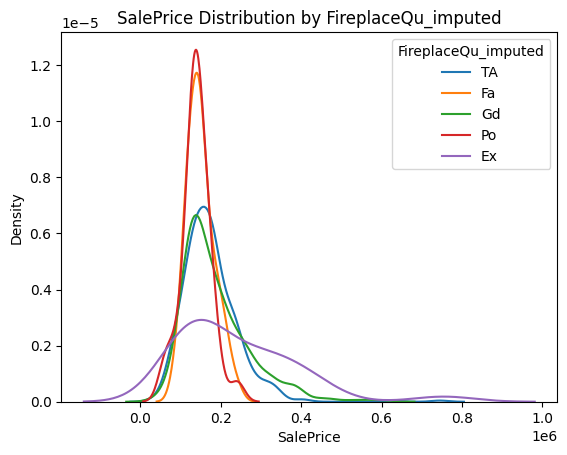

In [64]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]
                ['SalePrice'], label=category)
plt.legend(title="FireplaceQu_imputed")
plt.xlabel("SalePrice")
plt.ylabel("Density")
plt.title("SalePrice Distribution by FireplaceQu_imputed")
plt.show()